In [ ]:
#Librerias
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Conexion con drive

from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/Proyecto_TLS/"

Mounted at /content/drive


In [ ]:
#Datos de implementacion en LINUX
df_tls13 = pd.read_csv(ruta + "dataset_tls_1_3.csv")
df_tls12 = pd.read_csv(ruta + "dataset_tls_1_2.csv")
#Datos de implementacion en MAC
df_tls13mo = pd.read_csv(ruta + "dataset_tls_1_3_mac_open.csv")
df_tls12mo = pd.read_csv(ruta + "dataset_tls_1_2_mac_open.csv")

#Preparación de los datos linux


In [ ]:
#Agregamos las columnas con el protocolo y  el sistema donde se opero

df_tls13["Sistema"] = "Linux"
df_tls13["Protocolo"] = "TLS1.3"
df_tls12["Sistema"] = "Linux"
df_tls12["Protocolo"] = "TLS1.2"

In [ ]:
# Unimos los csv en un gran DataFrame para cada sistema operativo
df = pd.concat([df_tls13, df_tls12], ignore_index=True)
df_mac= pd.concat([df_tls13mo, df_tls12mo], ignore_index=True)


#Limpieza LINUX
df = df[df["status"] == "OK"]
df = df.dropna()
# Limpieza MAC
df_mac = df_mac[df_mac['status'] == 'OK'].copy()
# Eliminar la columna 'fase' del dataframe de Mac
df_mac = df_mac.drop(columns=['Fase'], errors='ignore')
df_mac['handshake_ms'] = pd.to_numeric(df_mac['handshake_ms'], errors='coerce')
df_mac['valor_num'] = pd.to_numeric(df_mac['Valor_o_Latencia'], errors='coerce')


In [ ]:
columnas = ["time_connect", "time_appconnect", "time_total"]

# Procesar Linux
for col in columnas:
    if col in df.columns:
        df[col] = df[col] * 1000

df = df.rename(columns={
    "time_connect": "time_connect_ms",
    "time_appconnect": "time_appconnect_ms",
    "time_total": "time_total_ms"
})


In [ ]:
# 1. Definimos las columnas que queremos que existan en AMBOS
columnas_tiempo = ["time_connect", "time_appconnect", "time_total", "handshake_ms"]

# --- PROCESAR LINUX ---
for col in columnas_tiempo:
    if col in df.columns:
        if df[col].mean() < 10:
            df[col] = df[col] * 1000
    else:
        df[col] = pd.NA

# --- PROCESAR MAC ---
for col in columnas_tiempo:
    if col in df_mac.columns:
        # SI EL DATO ES > 10000, ES QUE SE MULTIPLICÓ POR ERROR (como vimos en tu imagen)
        # Lo corregimos dividiendo entre 1000 para regresar a ms reales
        if df_mac[col].mean() > 5000:
            df_mac[col] = df_mac[col] / 1000

        # Si el dato es muy pequeño (< 10), es que venía en segundos -> multiplicamos
        elif df_mac[col].mean() < 10:
            df_mac[col] = df_mac[col] * 1000
    else:
        # Si Mac no tiene la columna (como time_connect), la creamos vacía
        df_mac[col] = pd.NA

# 2. Renombrar todas para que terminen en _ms y sean idénticas
rename_map = {c: f"{c}_ms" if not c.endswith("_ms") else c for c in columnas_tiempo}

df = df.rename(columns=rename_map)
df_mac = df_mac.rename(columns=rename_map)


In [ ]:
# COLUMNAS DE TIEMPO
columnas_tiempo = ["time_connect", "time_appconnect", "time_total", "handshake_ms"]

# =========================
# PROCESAR LINUX
# =========================

for col in columnas_tiempo:
    if col in df.columns and df[col].mean() < 10:
        df[col] = df[col] * 1000

# =========================
# PROCESAR MAC
# =========================

for col in columnas_tiempo:
    if col in df_mac.columns:

        if df_mac[col].mean() > 5000:
            df_mac[col] = df_mac[col] / 1000

        elif df_mac[col].mean() < 10:
            df_mac[col] = df_mac[col] * 1000

# =========================
# RENOMBRAR COLUMNAS
# =========================

rename_map = {
    "time_connect": "time_connect_ms",
    "time_appconnect": "time_appconnect_ms",
    "time_total": "time_total_ms",
    "handshake_ms": "handshake_ms"
}

df = df.rename(columns=rename_map)
df_mac = df_mac.rename(columns=rename_map)


In [ ]:
#Dataframe de cada variable individual

#Latencia
df_lat = df[df["Variable"] == "Latencia"].copy()
df_lat["Valor"] = pd.to_numeric(df_lat["Valor"], errors="coerce")
df_lat = df_lat.sort_values(by="Valor")

#Perdida
df_perd = df[df["Variable"] == "Perdida"].copy()
df_perd["Valor"] = pd.to_numeric(df_perd["Valor"], errors="coerce")
df_perd = df_perd.sort_values(by="Valor")

#Jitter
df_jit = df[df["Variable"] == "Jitter"].copy()
df_jit["Valor"] = pd.to_numeric(df_jit["Valor"], errors="coerce")
df_jit = df_jit.sort_values(by="Valor")

#Mac

# Separar por variables
df_mac_lat = df_mac[df_mac['Variable_o_Escenario'] == 'Latencia'].sort_values('valor_num')
df_mac_perd = df_mac[df_mac['Variable_o_Escenario'] == 'Perdida']
df_mac_jit = df_mac[df_mac['Variable_o_Escenario'] == 'Jitter']


##Metricas de evaluacion

In [ ]:
#Promedio de las iteraciones para cada parametro
prom_lat = df_lat.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()
prom_perd = df_perd.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()
prom_jit = df_jit.groupby(["Valor","Protocolo"])["handshake_ms"].mean().reset_index()

In [ ]:
# ESTADÍSTICAS DESCRIPTIVAS

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("\n========== LATENCIA ==========\n")
print(df_lat.groupby(["Valor", "Protocolo"])["handshake_ms"].describe().reset_index())

print("\n========== PERDIDA ==========\n")
print(df_perd.groupby(["Valor", "Protocolo"])["handshake_ms"].describe().reset_index())

print("\n========== JITTER ==========\n")
print(df_jit.groupby(["Valor", "Protocolo"])["handshake_ms"].describe().reset_index())


========== LATENCIA ==========

   Valor Protocolo  count       mean        std      min        25%       50%  \
0      0    TLS1.2   50.0   61.71778  15.456488   53.022   55.25075   56.6640   
1      0    TLS1.3   50.0   42.46960   3.020915   39.662   40.94850   41.5375   
2     50    TLS1.2   50.0  159.42896   4.412536  154.324  156.48800  157.7365   
3     50    TLS1.3   50.0   92.40338   1.487086   90.384   91.49750   92.1630   
4    100    TLS1.2   50.0  259.40320   5.982578  254.098  256.60050  257.7825   
5    100    TLS1.3   50.0  144.19378   3.772446  140.448  141.87300  143.1885   
6    200    TLS1.2   50.0  462.40484   9.167014  454.863  457.49475  459.0270   
7    200    TLS1.3   50.0  246.63692   6.012718  240.468  242.52250  243.7875   
8    300    TLS1.2   50.0  669.47182  38.607660  654.957  657.23000  658.2575   
9    300    TLS1.3   50.0  344.12470   3.974389  340.711  342.26200  343.1120   

         75%      max  
0   59.65575  139.534  
1   42.70375   54.741  
2  

##Graficas

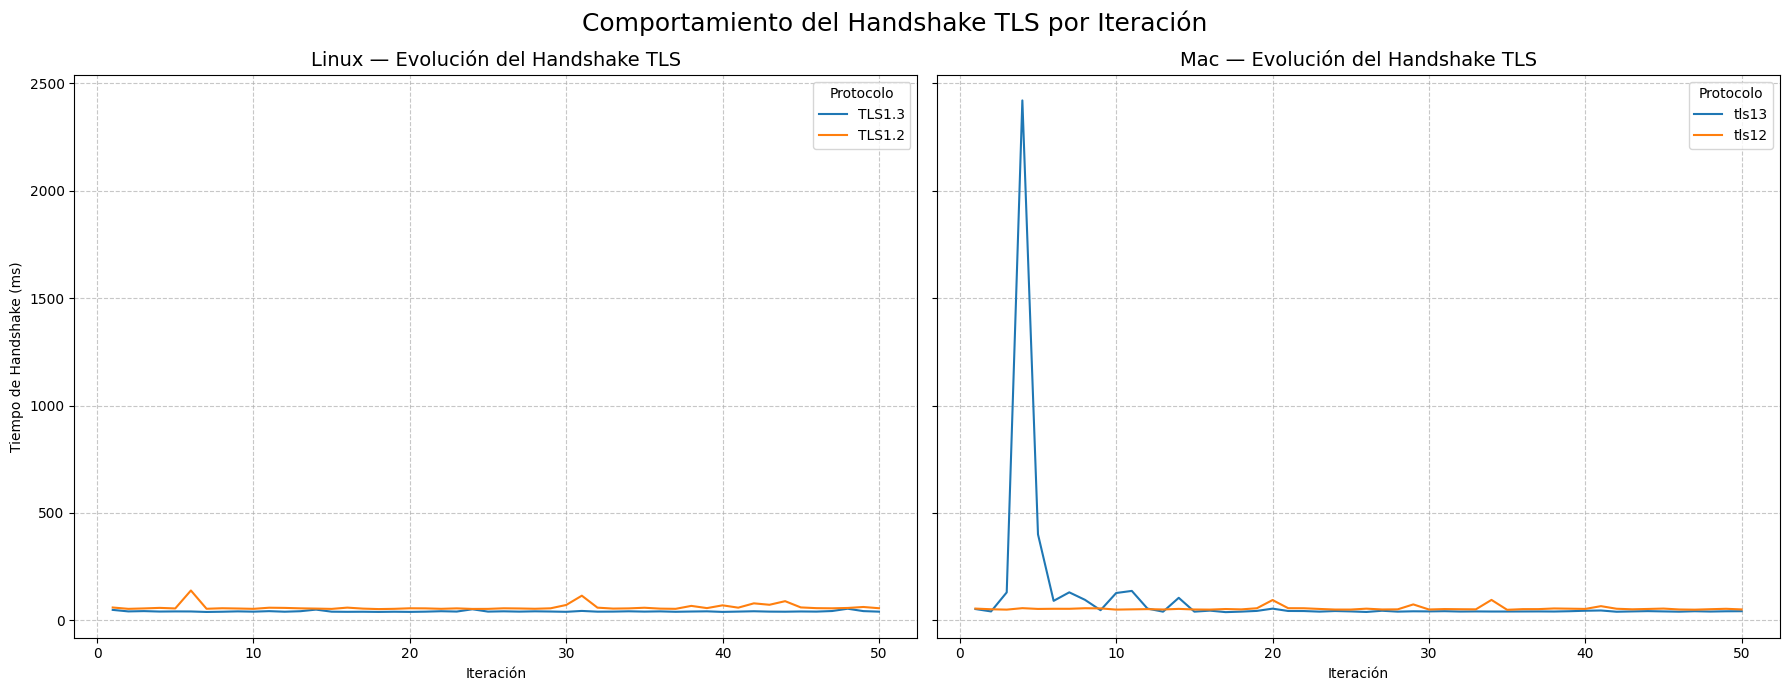

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18,7), sharey=True)

# LINUX
df_lat_real_linux = df_lat[df_lat["Valor"] == 0]

sns.lineplot(data=df_lat_real_linux,x="Iteracion",y="handshake_ms",hue="Protocolo",errorbar=None,ax=axes[0])
axes[0].set_title("Linux — Comportamiento del Handshake TLS", fontsize=14)
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("Tiempo de Handshake (ms)")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title="Protocolo")

# MAC
df_lat_real_mac = df_mac_lat[df_mac_lat["valor_num"] == 0]

sns.lineplot(data=df_lat_real_mac,x="Iteracion",y="handshake_ms",hue="TLS",errorbar=None,ax=axes[1])
axes[1].set_title("Mac — Comportamiento del Handshake TLS", fontsize=14)
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Tiempo de Handshake (ms)")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title="Protocolo")

plt.suptitle("Comportamiento del Handshake TLS por Iteración", fontsize=18)

plt.tight_layout()
plt.show()

###Grafica de promedios (Rregresion)

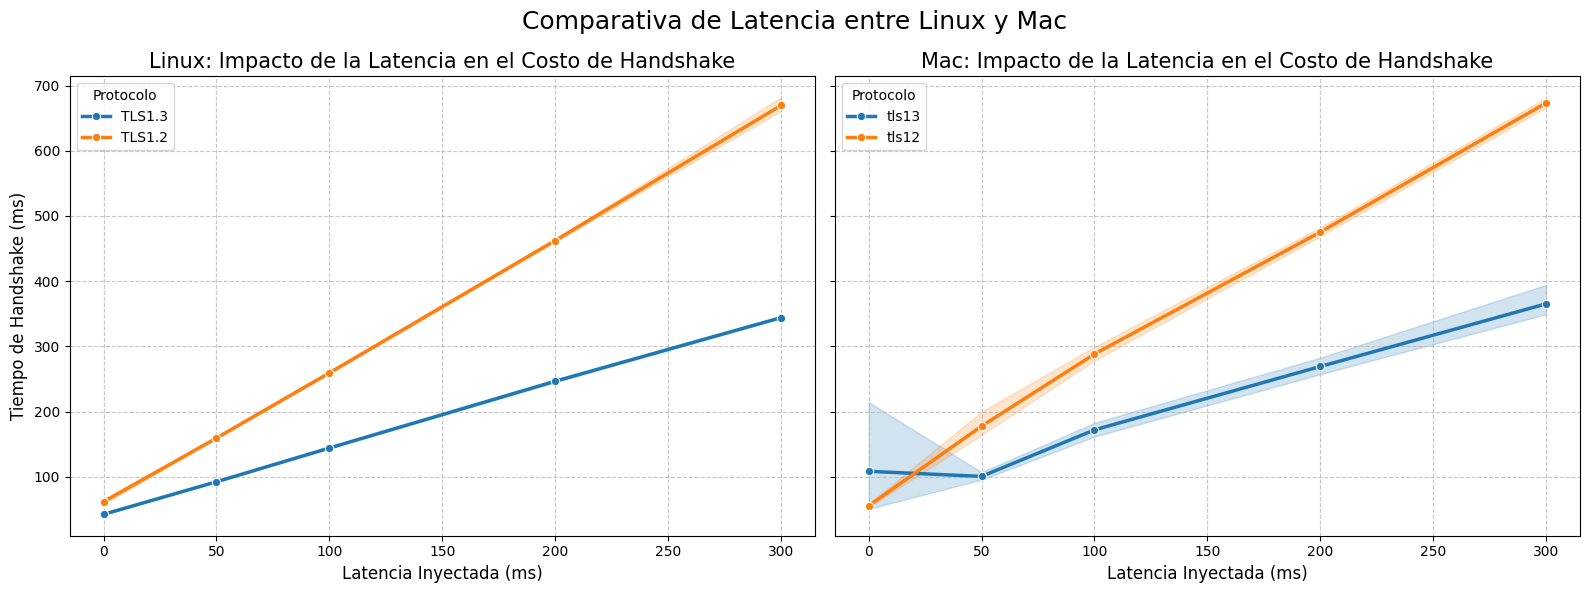

In [ ]:
# COMPARATIVA DE LATENCIA

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# LINUX

sns.lineplot(data=df_lat, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2.5, ax=axes[0])

axes[0].set_title('Linux: Impacto de la Latencia en el Costo de Handshake', fontsize=15)
axes[0].set_xlabel('Latencia Inyectada (ms)', fontsize=12)
axes[0].set_ylabel('Tiempo de Handshake (ms)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title='Protocolo')

# MAC

sns.lineplot(data=df_mac_lat, x='valor_num', y='handshake_ms', hue='TLS', marker='o', linewidth=2.5, ax=axes[1])

axes[1].set_title('Mac: Impacto de la Latencia en el Costo de Handshake', fontsize=15)
axes[1].set_xlabel('Latencia Inyectada (ms)', fontsize=12)
axes[1].set_ylabel('Tiempo de Handshake (ms)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title='Protocolo')


plt.suptitle('Comparativa de Latencia entre Linux y Mac', fontsize=18)
plt.tight_layout()
plt.show()

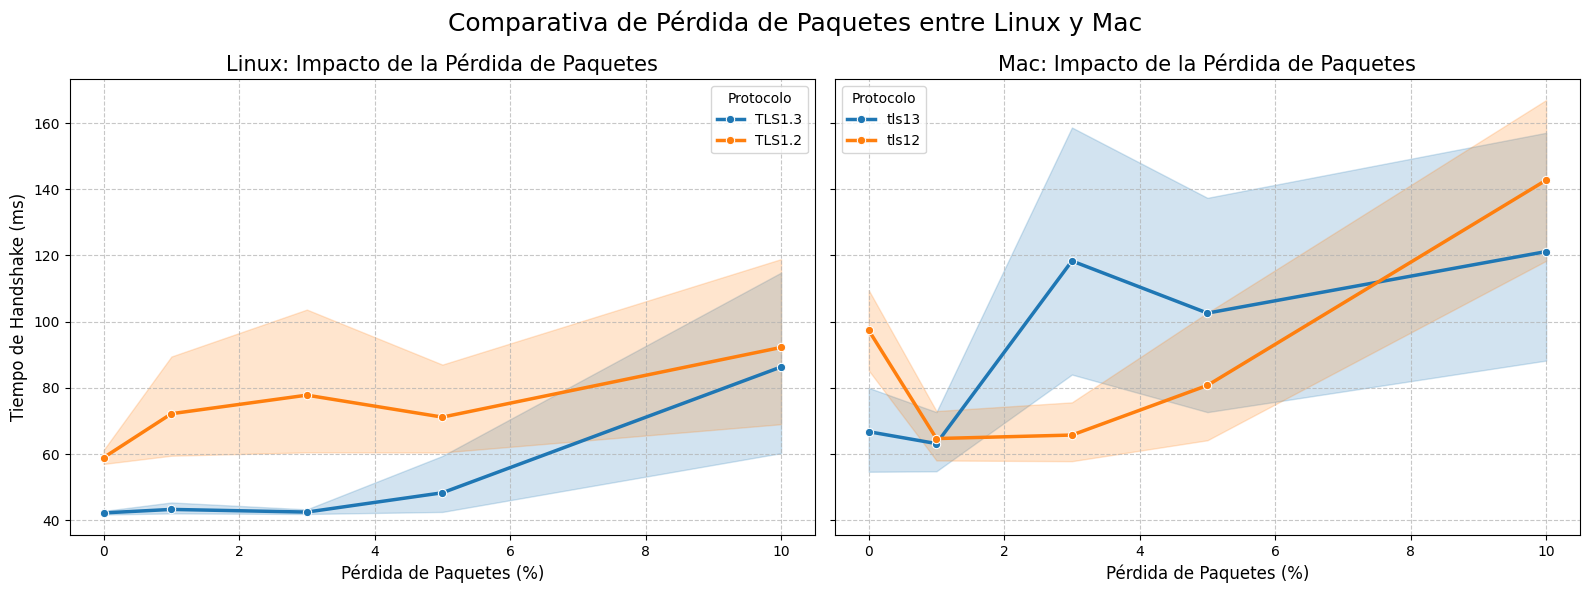

In [ ]:
# COMPARATIVA DE PÉRDIDA DE PAQUETES

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# LINUX

sns.lineplot(data=df_perd, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2.5, ax=axes[0])

axes[0].set_title('Linux: Impacto de la Pérdida de Paquetes', fontsize=15)
axes[0].set_xlabel('Pérdida de Paquetes (%)', fontsize=12)
axes[0].set_ylabel('Tiempo de Handshake (ms)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title='Protocolo')

# MAC

sns.lineplot(data=df_mac_perd, x='valor_num', y='handshake_ms', hue='TLS', marker='o', linewidth=2.5, ax=axes[1])

axes[1].set_title('Mac: Impacto de la Pérdida de Paquetes', fontsize=15)
axes[1].set_xlabel('Pérdida de Paquetes (%)', fontsize=12)
axes[1].set_ylabel('Tiempo de Handshake (ms)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title='Protocolo')


plt.suptitle('Comparativa de Pérdida de Paquetes entre Linux y Mac', fontsize=18)
plt.tight_layout()
plt.show()

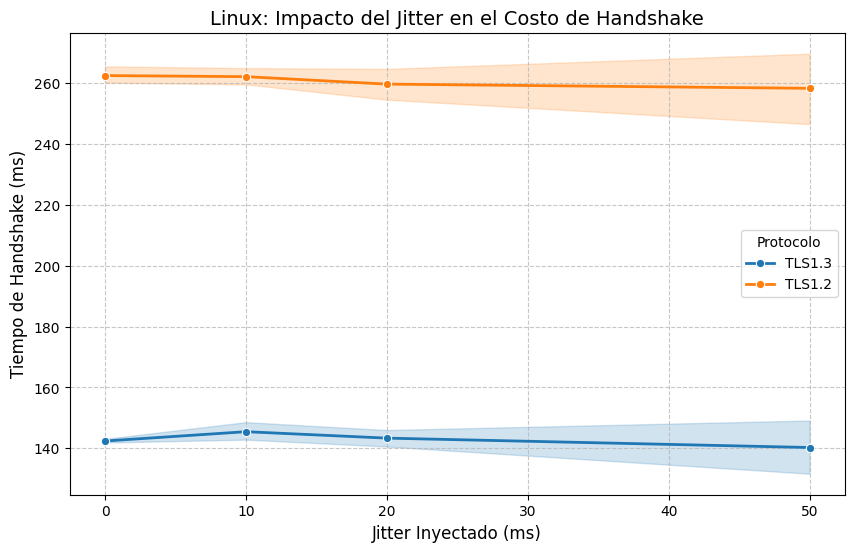

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos lineplot para ver la tendencia
sns.lineplot(data=df_jit, x='Valor', y='handshake_ms', hue='Protocolo', marker='o', linewidth=2)

plt.title('Linux: Impacto del Jitter en el Costo de Handshake', fontsize=14)
plt.xlabel('Jitter Inyectado (ms)', fontsize=12)
plt.ylabel('Tiempo de Handshake (ms)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Protocolo')
plt.show()

### Graica de datos (Dispersión)

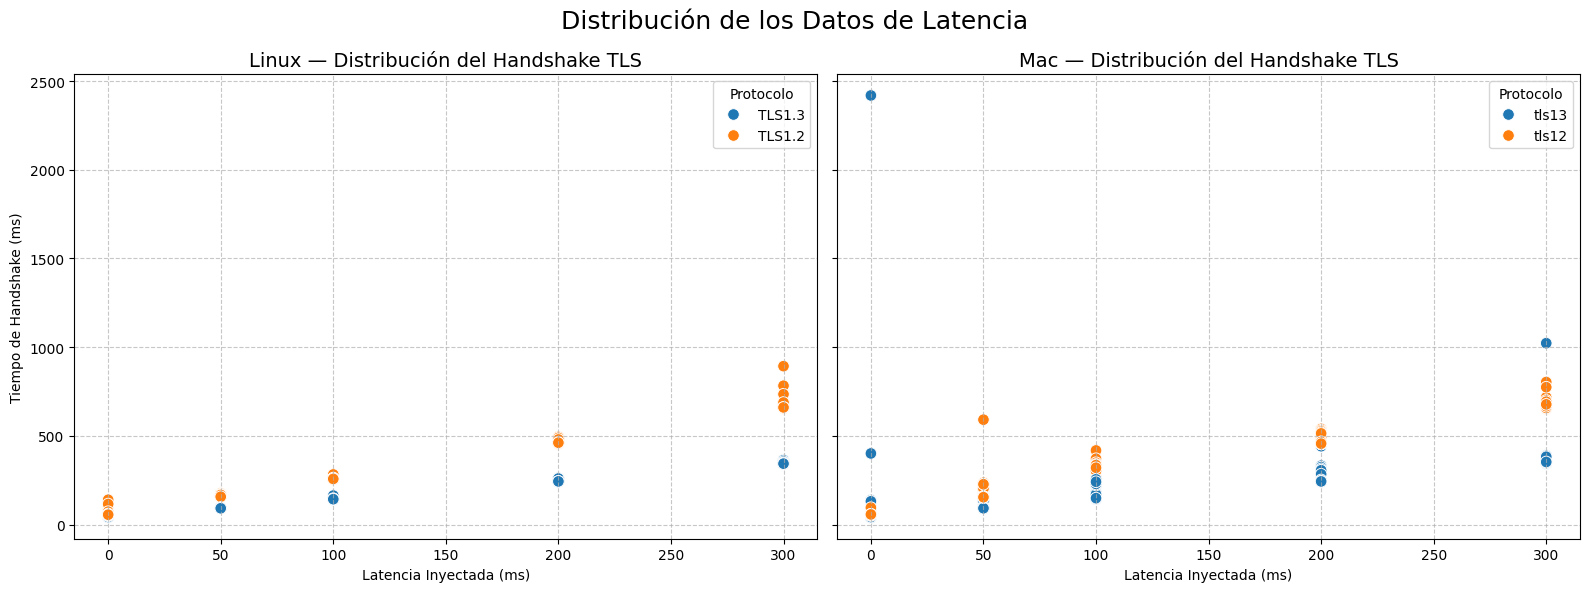

In [ ]:
# LATENCIA

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# LINUX

sns.scatterplot(data=df_lat, x="Valor", y="handshake_ms", hue="Protocolo", s=70, ax=axes[0])

axes[0].set_title("Linux — Distribución del Handshake TLS", fontsize=14)
axes[0].set_xlabel("Latencia Inyectada (ms)")
axes[0].set_ylabel("Tiempo de Handshake (ms)")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title="Protocolo")

# MAC

sns.scatterplot(data=df_mac_lat, x="valor_num", y="handshake_ms", hue="TLS", s=70, ax=axes[1])

axes[1].set_title("Mac — Distribución del Handshake TLS", fontsize=14)
axes[1].set_xlabel("Latencia Inyectada (ms)")
axes[1].set_ylabel("Tiempo de Handshake (ms)")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title="Protocolo")


plt.suptitle("Distribución de los Datos de Latencia", fontsize=18)
plt.tight_layout()
plt.show()

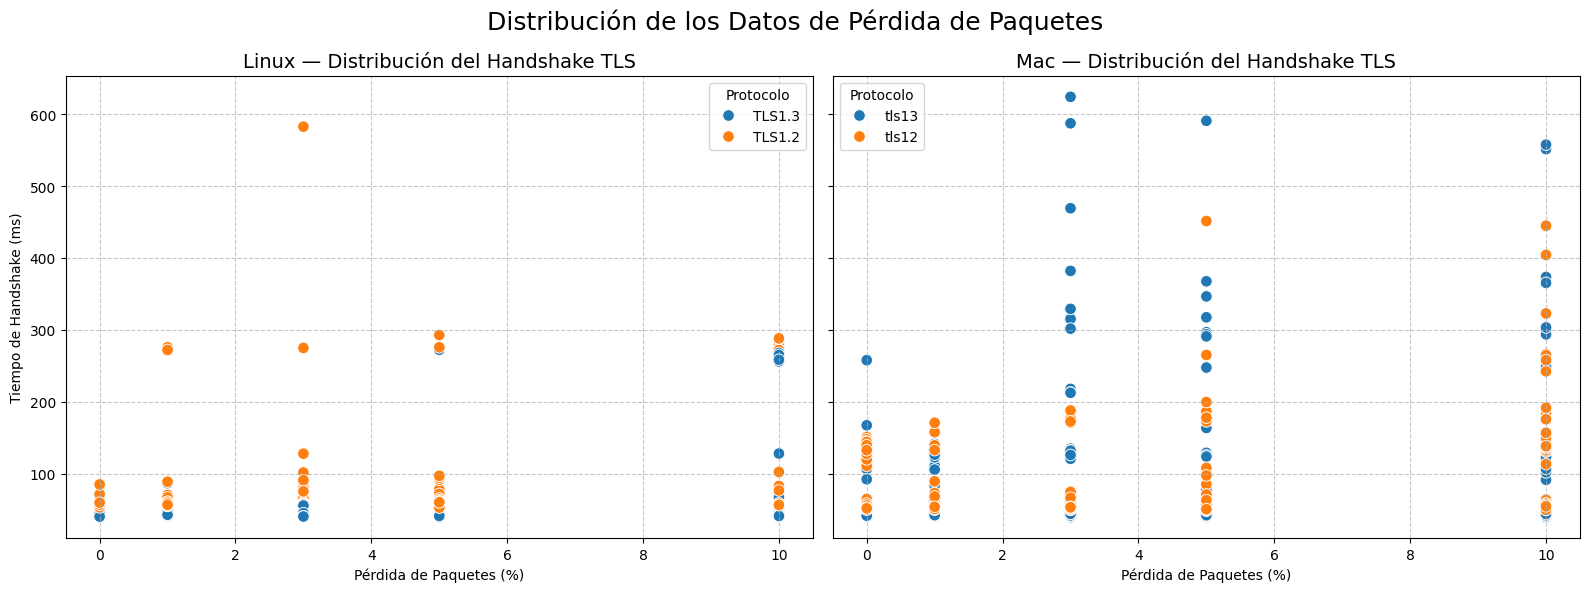

In [ ]:
# PERDIDA

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# LINUX

sns.scatterplot(data=df_perd, x="Valor", y="handshake_ms", hue="Protocolo", s=70, ax=axes[0])

axes[0].set_title("Linux — Distribución del Handshake TLS", fontsize=14)
axes[0].set_xlabel("Pérdida de Paquetes (%)")
axes[0].set_ylabel("Tiempo de Handshake (ms)")
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(title="Protocolo")

# MAC

sns.scatterplot(data=df_mac_perd, x="valor_num", y="handshake_ms", hue="TLS", s=70, ax=axes[1])

axes[1].set_title("Mac — Distribución del Handshake TLS", fontsize=14)
axes[1].set_xlabel("Pérdida de Paquetes (%)")
axes[1].set_ylabel("Tiempo de Handshake (ms)")
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title="Protocolo")

plt.suptitle("Distribución de los Datos de Pérdida de Paquetes", fontsize=18)

plt.tight_layout()

plt.show()

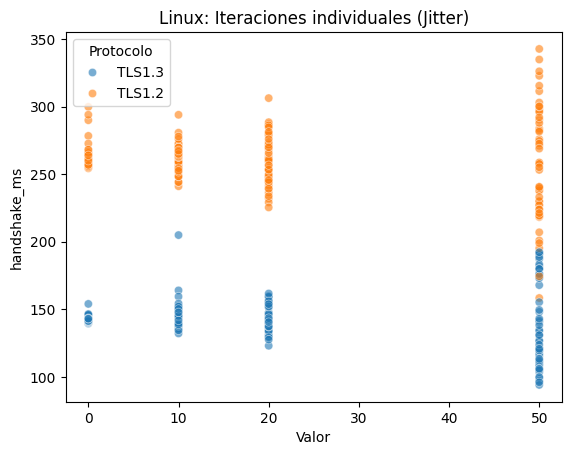

In [ ]:
sns.scatterplot(data=df_jit, x="Valor", y="handshake_ms", hue="Protocolo", alpha=0.6)

plt.title("Linux: Iteraciones individuales (Jitter)")
plt.show()

### Graficas de diferencias

como se distribuyen las mediciones los picos representan las concentraciones de datos

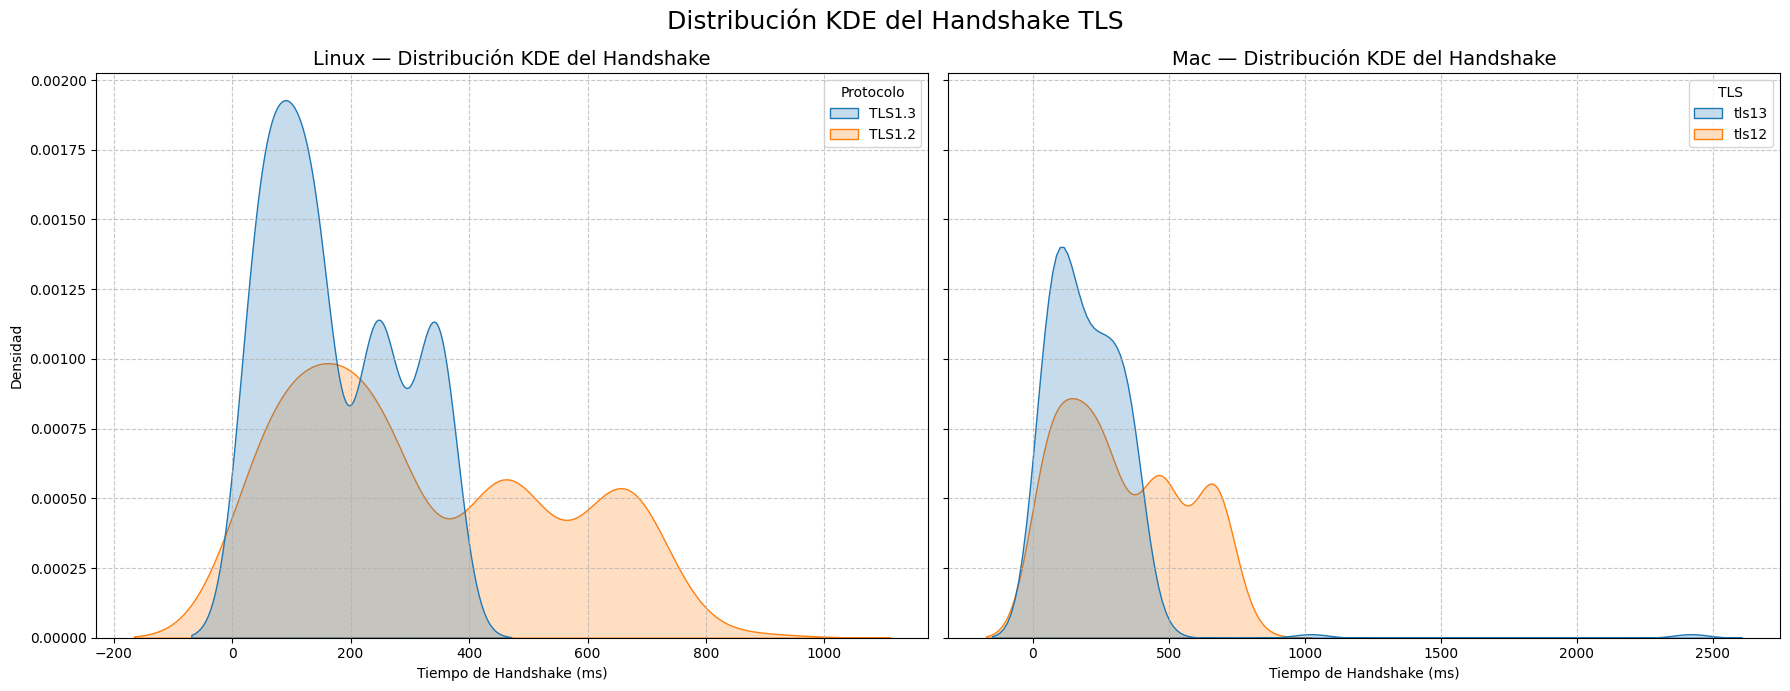

In [ ]:
# KDE Latencia
fig, axes = plt.subplots(1, 2, figsize=(18,7), sharey=True)

# LINUX
sns.kdeplot(data=df_lat,x="handshake_ms",hue="Protocolo",fill=True,ax=axes[0])
axes[0].set_title("Linux — Distribución KDE del Handshake", fontsize=14)
axes[0].set_xlabel("Tiempo de Handshake (ms)")
axes[0].set_ylabel("Densidad")
axes[0].grid(True, linestyle='--', alpha=0.7)

# MAC
sns.kdeplot(data=df_mac_lat,x="handshake_ms",hue="TLS",fill=True,ax=axes[1])
axes[1].set_title("Mac — Distribución KDE del Handshake", fontsize=14)
axes[1].set_xlabel("Tiempo de Handshake (ms)")
axes[1].set_ylabel("Densidad")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Distribución KDE del Handshake TLS", fontsize=18)
plt.tight_layout()
plt.show()

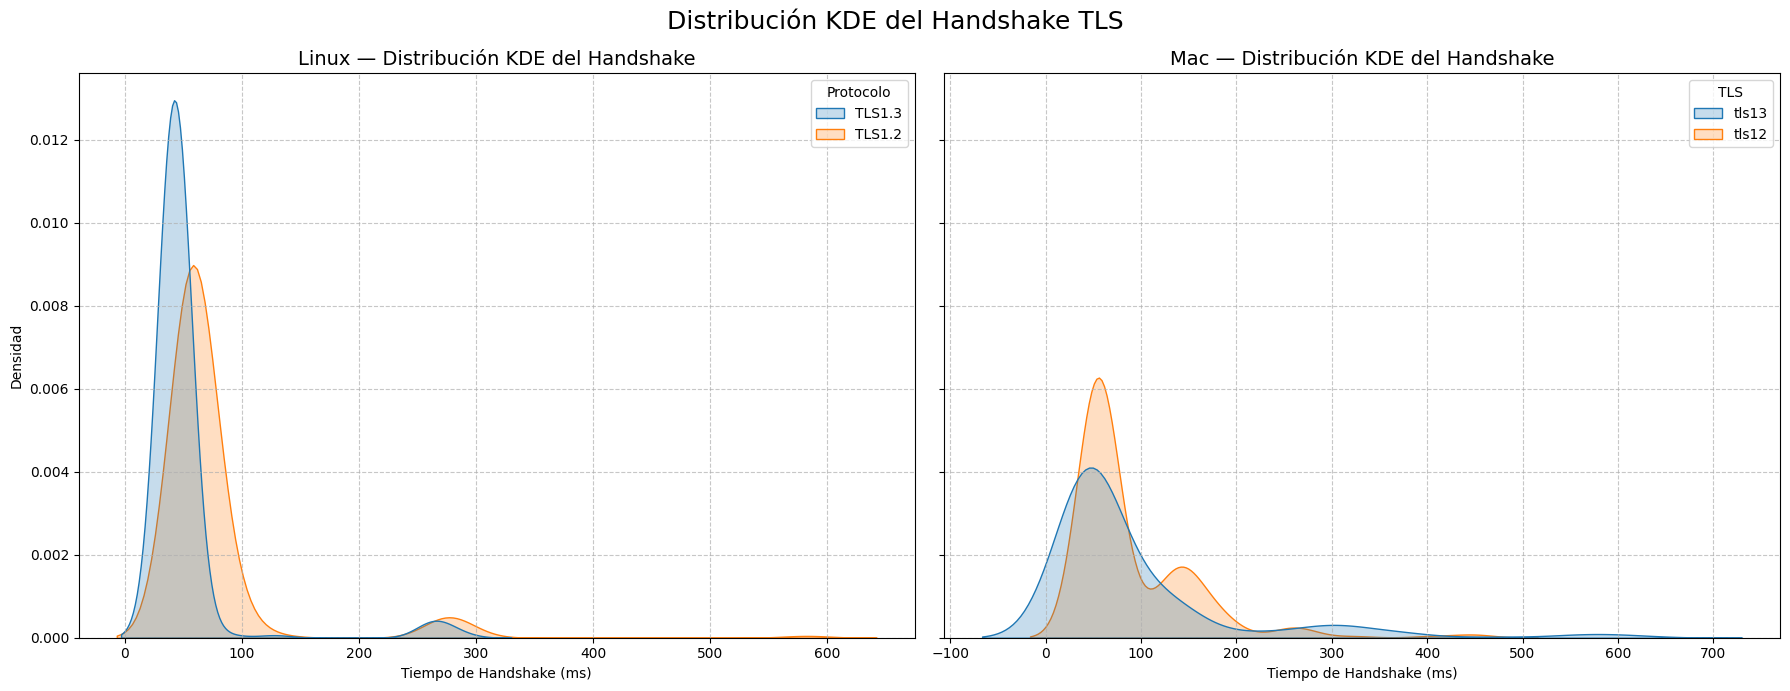

In [ ]:
# KDE Perdida
fig, axes = plt.subplots(1, 2, figsize=(18,7), sharey=True)

# LINUX
sns.kdeplot(data=df_perd,x="handshake_ms",hue="Protocolo",fill=True,ax=axes[0])
axes[0].set_title("Linux — Distribución KDE del Handshake", fontsize=14)
axes[0].set_xlabel("Tiempo de Handshake (ms)")
axes[0].set_ylabel("Densidad")
axes[0].grid(True, linestyle='--', alpha=0.7)

# MAC
sns.kdeplot(data=df_mac_perd,x="handshake_ms",hue="TLS",fill=True,ax=axes[1])
axes[1].set_title("Mac — Distribución KDE del Handshake", fontsize=14)
axes[1].set_xlabel("Tiempo de Handshake (ms)")
axes[1].set_ylabel("Densidad")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Distribución KDE del Handshake TLS", fontsize=18)
plt.tight_layout()
plt.show()

<Axes: xlabel='handshake_ms', ylabel='Density'>

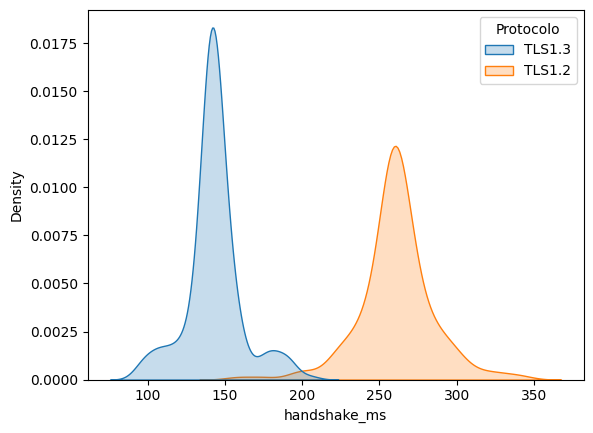

In [ ]:
sns.kdeplot(data=df_jit,x="handshake_ms",hue="Protocolo",fill=True)

que variable impacta mas

<Axes: >

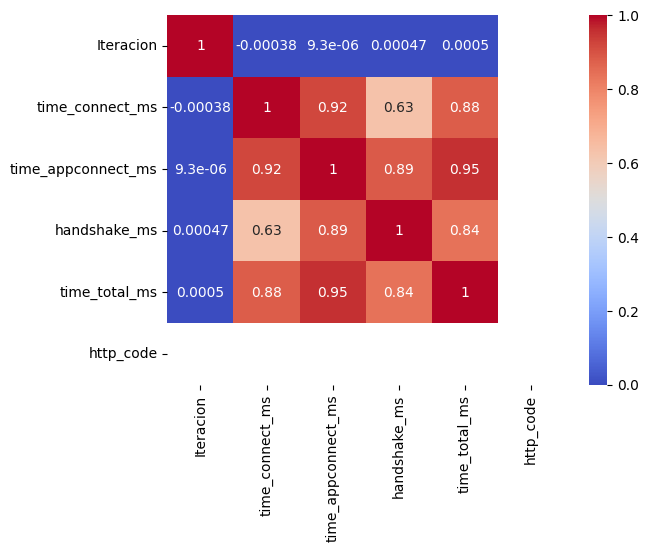

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

In [ ]:
# CORRELACIONES LINUX
corr_lat_12_linux = df_lat[df_lat["Protocolo"] == "TLS1.2"]["Valor"].corr(df_lat[df_lat["Protocolo"] == "TLS1.2"]["handshake_ms"])
corr_lat_13_linux = df_lat[df_lat["Protocolo"] == "TLS1.3"]["Valor"].corr(df_lat[df_lat["Protocolo"] == "TLS1.3"]["handshake_ms"])

corr_perd_12_linux = df_perd[df_perd["Protocolo"] == "TLS1.2"]["Valor"].corr(df_perd[df_perd["Protocolo"] == "TLS1.2"]["handshake_ms"])
corr_perd_13_linux = df_perd[df_perd["Protocolo"] == "TLS1.3"]["Valor"].corr(df_perd[df_perd["Protocolo"] == "TLS1.3"]["handshake_ms"])

corr_jit_12_linux = df_jit[df_jit["Protocolo"] == "TLS1.2"]["Valor"].corr(df_jit[df_jit["Protocolo"] == "TLS1.2"]["handshake_ms"])
corr_jit_13_linux = df_jit[df_jit["Protocolo"] == "TLS1.3"]["Valor"].corr(df_jit[df_jit["Protocolo"] == "TLS1.3"]["handshake_ms"])

# CORRELACIONES MAC
corr_lat_12_mac = df_mac_lat[df_mac_lat["TLS"] == "tls12"]["valor_num"].corr(df_mac_lat[df_mac_lat["TLS"] == "tls12"]["handshake_ms"])
corr_lat_13_mac = df_mac_lat[df_mac_lat["TLS"] == "tls13"]["valor_num"].corr(df_mac_lat[df_mac_lat["TLS"] == "tls13"]["handshake_ms"])

corr_perd_12_mac = df_mac_perd[df_mac_perd["TLS"] == "tls12"]["valor_num"].corr(df_mac_perd[df_mac_perd["TLS"] == "tls12"]["handshake_ms"])
corr_perd_13_mac = df_mac_perd[df_mac_perd["TLS"] == "tls13"]["valor_num"].corr(df_mac_perd[df_mac_perd["TLS"] == "tls13"]["handshake_ms"])

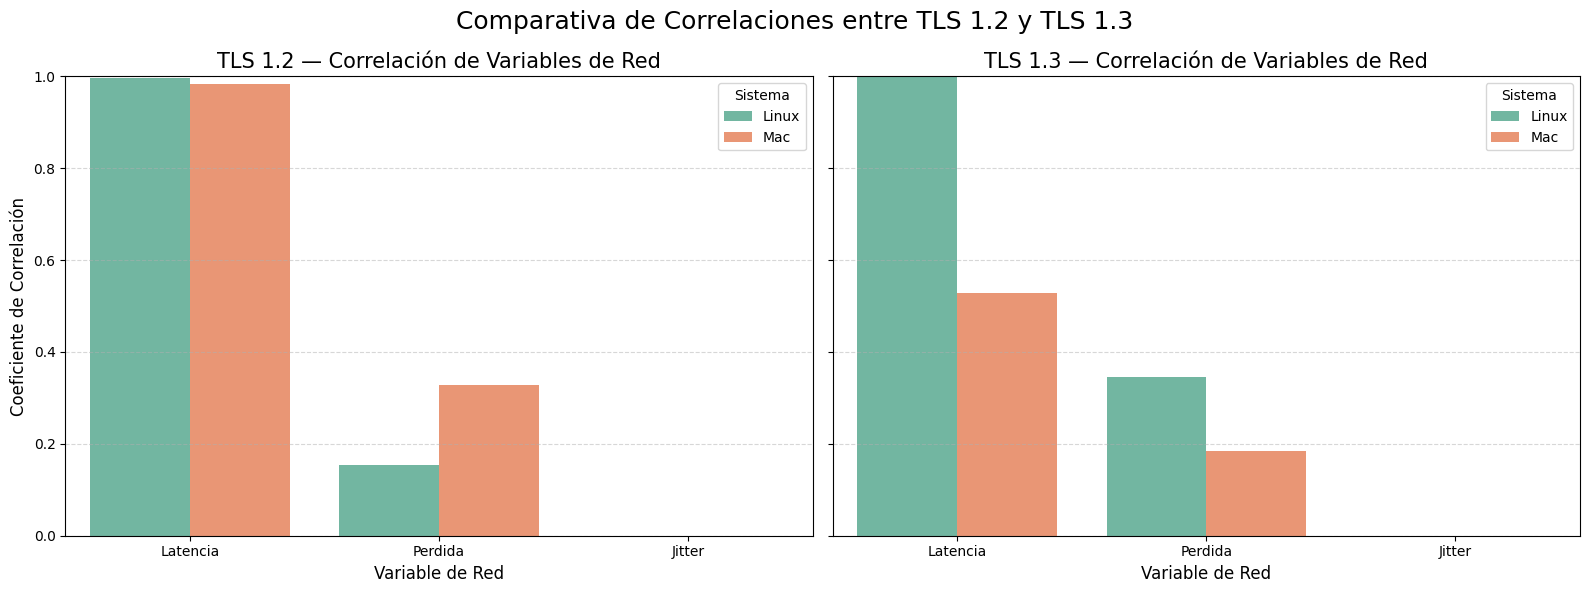

In [ ]:
# TLS 1.2
tabla_tls12 = pd.DataFrame({

    "Sistema": [
        "Linux", "Linux", "Linux",
        "Mac", "Mac"],

    "Variable": [
        "Latencia",
        "Perdida",
        "Jitter",
        "Latencia",
        "Perdida"],

    "Correlacion": [
        corr_lat_12_linux,
        corr_perd_12_linux,
        corr_jit_12_linux,

        corr_lat_12_mac,
        corr_perd_12_mac]})

# TLS 1.3
tabla_tls13 = pd.DataFrame({
    "Sistema": [
        "Linux", "Linux", "Linux",
        "Mac", "Mac"],

    "Variable": [
        "Latencia",
        "Perdida",
        "Jitter",
        "Latencia",
        "Perdida"],

    "Correlacion": [
        corr_lat_13_linux,
        corr_perd_13_linux,
        corr_jit_13_linux,

        corr_lat_13_mac,
        corr_perd_13_mac]})

# GRAFICAS

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# TLS 1.2
sns.barplot(data=tabla_tls12,x="Variable",y="Correlacion",hue="Sistema",palette="Set2",ax=axes[0])
axes[0].set_title("TLS 1.2 — Correlación de Variables de Red",fontsize=15)
axes[0].set_xlabel("Variable de Red",fontsize=12)
axes[0].set_ylabel("Coeficiente de Correlación",fontsize=12)
axes[0].set_ylim(0,1)
axes[0].grid(axis='y',linestyle='--',alpha=0.5)
axes[0].legend(title="Sistema")

# TLS 1.3
sns.barplot(data=tabla_tls13,x="Variable",y="Correlacion",hue="Sistema",palette="Set2",ax=axes[1])
axes[1].set_title("TLS 1.3 — Correlación de Variables de Red",fontsize=15)
axes[1].set_xlabel("Variable de Red",fontsize=12)
axes[1].set_ylabel("Coeficiente de Correlación",fontsize=12)
axes[1].set_ylim(0,1)
axes[1].grid(axis='y',linestyle='--',alpha=0.5)
axes[1].legend(title="Sistema")

plt.suptitle("Comparativa de Correlaciones entre TLS 1.2 y TLS 1.3",fontsize=18)
plt.tight_layout()
plt.show()